1. Cargar librerias
2. Cargar dataset
3. Revisar datos
5. Arreglar columna name
6. Arreglar formato fechas
7. Convertir sold units a números
8. Arreglar columna currency
9. Arreglar columna Profit Margin
10. Eliminar registros NaN
11. Revisar datos limpios
12. Graficar y analizar resultados

**1. Cargar librerias**

In [6]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**2. Cargar dataset**

In [8]:
df = pd.read_excel("/content/drive/MyDrive/Ciencia De Datos/Limpieza/messy_sales.xlsx")
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,north,tablet,electronics,32,USD 858,########,0.1
1,2024-01-30,north,Tablet,Electronics,72,833.83,########,15 percent
2,2024-02-13,EAST,laptop,ELEC,NaN,489.12,NaN,0.08
3,2024-04-28,West,Laptop,gadget,thirty,733.46,########,0.1
4,2024-02-18,EAST,Phone,ELEC,47,USD 373,40920,0.1


**3. Revisar datos**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               200 non-null    datetime64[ns]
 1   Region             200 non-null    object        
 2   Product            200 non-null    object        
 3   Category           200 non-null    object        
 4   Units Sold         196 non-null    object        
 5   Unit Price         200 non-null    object        
 6   Total Sales        197 non-null    object        
 7   Profit Margin (%)  200 non-null    object        
dtypes: datetime64[ns](1), object(7)
memory usage: 12.6+ KB


In [10]:
df.isnull().sum()

,0
Date,0
Region,0
Product,0
Category,0
Units Sold,4
Unit Price,0
Total Sales,3
Profit Margin (%),0


**4. Gestionar datos faltantes**

In [11]:
# Asegurar que las columnas numericas con numeros
df['Units Sold'] = pd.to_numeric(df['Units Sold'], errors='coerce')
df['Total Sales'] = pd.to_numeric(df['Total Sales'], errors='coerce')
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,north,tablet,electronics,32.0,USD 858,NaN,0.1
1,2024-01-30,north,Tablet,Electronics,72.0,833.83,NaN,15 percent
2,2024-02-13,EAST,laptop,ELEC,NaN,489.12,NaN,0.08
3,2024-04-28,West,Laptop,gadget,NaN,733.46,NaN,0.1
4,2024-02-18,EAST,Phone,ELEC,47.0,USD 373,40920.0,0.1


**5. Llenar valores numerico con el promedio**

In [12]:
df['Units Sold'] = df['Units Sold'].fillna(df['Units Sold'].mean())
df['Total Sales'] = df['Total Sales'].fillna(df['Total Sales'].mean())
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,north,tablet,electronics,32.000000,USD 858,26014.142857,0.1
1,2024-01-30,north,Tablet,Electronics,72.000000,833.83,26014.142857,15 percent
2,2024-02-13,EAST,laptop,ELEC,52.307692,489.12,26014.142857,0.08
3,2024-04-28,West,Laptop,gadget,52.307692,733.46,26014.142857,0.1
4,2024-02-18,EAST,Phone,ELEC,47.000000,USD 373,40920.000000,0.1


In [13]:
df.columns = df.columns.str.strip()
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,north,tablet,electronics,32.000000,USD 858,26014.142857,0.1
1,2024-01-30,north,Tablet,Electronics,72.000000,833.83,26014.142857,15 percent
2,2024-02-13,EAST,laptop,ELEC,52.307692,489.12,26014.142857,0.08
3,2024-04-28,West,Laptop,gadget,52.307692,733.46,26014.142857,0.1
4,2024-02-18,EAST,Phone,ELEC,47.000000,USD 373,40920.000000,0.1


In [14]:
df.Date = pd.to_datetime(df.Date, errors="coerce")
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,north,tablet,electronics,32.000000,USD 858,26014.142857,0.1
1,2024-01-30,north,Tablet,Electronics,72.000000,833.83,26014.142857,15 percent
2,2024-02-13,EAST,laptop,ELEC,52.307692,489.12,26014.142857,0.08
3,2024-04-28,West,Laptop,gadget,52.307692,733.46,26014.142857,0.1
4,2024-02-18,EAST,Phone,ELEC,47.000000,USD 373,40920.000000,0.1


**Estandarizar el texto de las columnas**

In [15]:
for col in ["Region", "Product", "Category"]:
  df[col] = df[col].str.strip().str.capitalize()
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,North,Tablet,Electronics,32.000000,USD 858,26014.142857,0.1
1,2024-01-30,North,Tablet,Electronics,72.000000,833.83,26014.142857,15 percent
2,2024-02-13,East,Laptop,Elec,52.307692,489.12,26014.142857,0.08
3,2024-04-28,West,Laptop,Gadget,52.307692,733.46,26014.142857,0.1
4,2024-02-18,East,Phone,Elec,47.000000,USD 373,40920.000000,0.1


**8. Limpiar columna currency** (Unit Price, Total Sale)

In [16]:
for col in ["Unit Price", "Total Sales"]:
  df[col] = df[col].astype(str)
  df[col] = (df[col].str.replace("$, USD", "", regex=True).str.strip())
  df[col] = pd.to_numeric(df[col], errors="coerce")
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,North,Tablet,Electronics,32.000000,NaN,26014.142857,0.1
1,2024-01-30,North,Tablet,Electronics,72.000000,833.83,26014.142857,15 percent
2,2024-02-13,East,Laptop,Elec,52.307692,489.12,26014.142857,0.08
3,2024-04-28,West,Laptop,Gadget,52.307692,733.46,26014.142857,0.1
4,2024-02-18,East,Phone,Elec,47.000000,NaN,40920.000000,0.1


**9. Arreglar Profit Margin**

In [17]:
df["Profit Margin (%)"] = (
    df["Profit Margin (%)"]
    .astype(str)
    .str.replace("%", "", regex=True)
    .str.replace("percent", "")
    .str.strip()
    .astype(float)
  )
df["Profit Margin (%)"] = pd.to_numeric(df["Profit Margin (%)"], errors="coerce")
df['Profit Margin (%)'] = np.where(df['Profit Margin (%)'] < 1, df['Profit Margin (%)']*100, df['Profit Margin (%)'])
df.sample(10)

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
164,2024-01-29,North,Monitor,Electronics,52.307692,657.54,26014.142857,8.0
86,2024-04-04,West,Tablet,Electronics,96.000000,NaN,15519.000000,10.0
24,2024-04-16,East,Laptop,Electronics,43.000000,NaN,26014.142857,10.0
147,2024-04-26,North,Desktop,Gadget,52.307692,NaN,26014.142857,8.0
150,2024-04-15,North,Desktop,Gadget,52.307692,240.13,26014.142857,15.0
62,2024-02-12,West,Tablet,Gadgets,52.307692,510.97,22186.000000,8.0
93,2024-04-08,North,Tablet,Elec,52.307692,126.77,47052.000000,8.0
178,2024-02-05,North,Desktop,Electronics,52.307692,790.55,13578.000000,8.0
27,2024-04-20,North,Monitor,Elec,35.000000,906.89,14079.000000,8.0
58,2024-01-10,North,Laptop,Electronics,52.307692,777.25,26014.142857,10.0


**Eliminar NaN**

In [18]:
df=df.dropna(subset=["Date", "Total Sales", "Region"])
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,North,Tablet,Electronics,32.000000,NaN,26014.142857,10.0
1,2024-01-30,North,Tablet,Electronics,72.000000,833.83,26014.142857,15.0
2,2024-02-13,East,Laptop,Elec,52.307692,489.12,26014.142857,8.0
3,2024-04-28,West,Laptop,Gadget,52.307692,733.46,26014.142857,10.0
4,2024-02-18,East,Phone,Elec,47.000000,NaN,40920.000000,10.0


**Graficar y analizar**

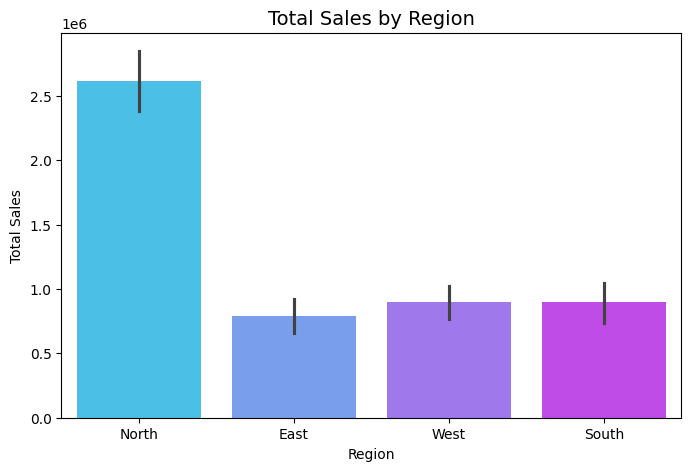

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Region", y ="Total Sales", estimator=sum, palette="cool")
plt.title("Total Sales by Region", fontsize=14)
plt.xticks(rotation=0)
plt.show()

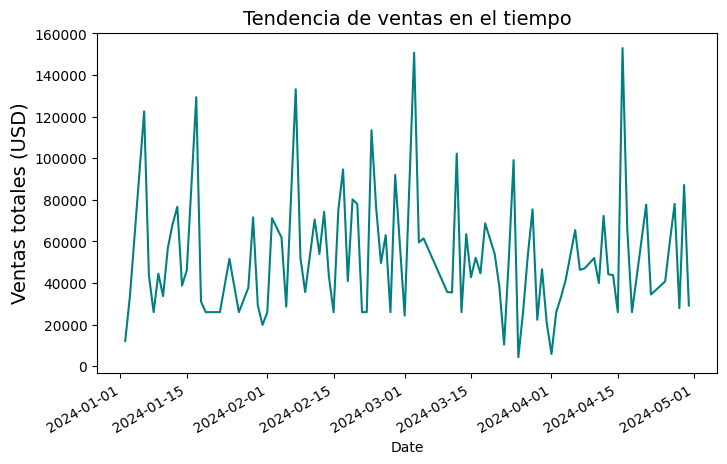

In [20]:
plt.figure(figsize=(8,5))
df.groupby("Date")["Total Sales"].sum().plot(kind="line", color="teal")
plt.title("Tendencia de ventas en el tiempo", fontsize=14)
plt.ylabel("Ventas totales (USD)", fontsize=14)
plt.xticks(rotation=30)
plt.show()

Tarea 1:
Realizar analisis por region con el grafico anterior

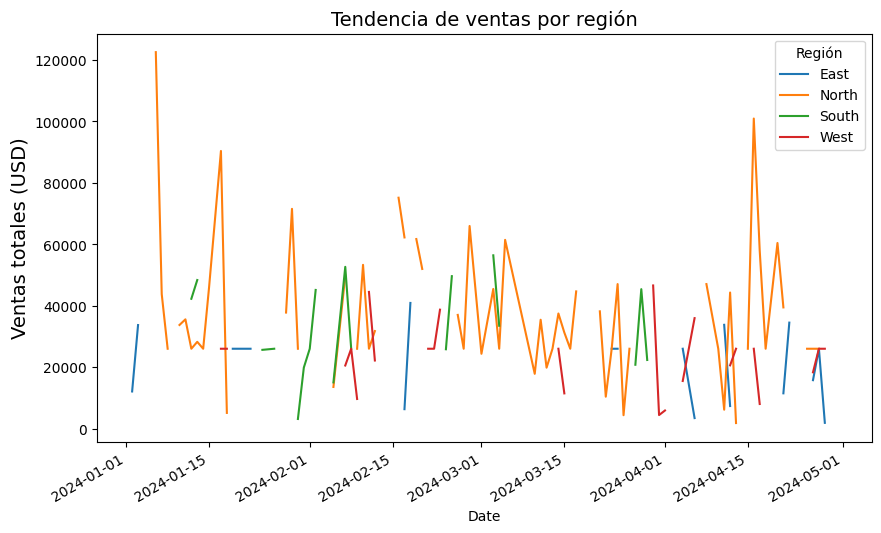

In [21]:
plt.figure(figsize=(10,6))

ventas_region = df.groupby(["Date", "Region"])["Total Sales"].sum().unstack()
ventas_region.plot(kind="line", ax=plt.gca())

plt.title("Tendencia de ventas por región", fontsize=14)
plt.ylabel("Ventas totales (USD)", fontsize=14)
plt.xticks(rotation=30)
plt.legend(title="Región")
plt.show()

Analisis por torta

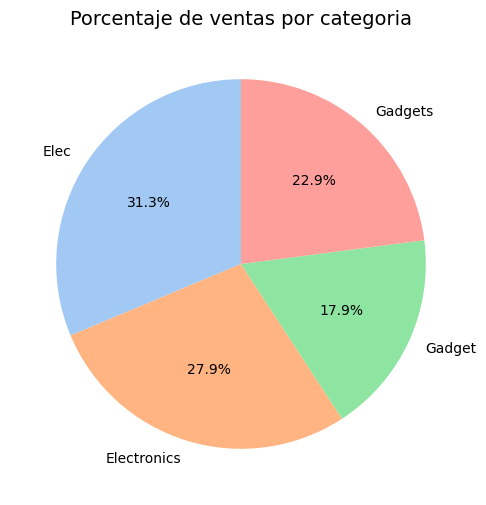

In [28]:
plt.figure(figsize=(6,6))
category_sales = df.groupby("Category")["Total Sales"].sum()
plt.pie(category_sales, labels=category_sales.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Porcentaje de ventas por categoria", fontsize=14)
plt.show()

**Unir Elec y Electronics, con Gadget y gat**

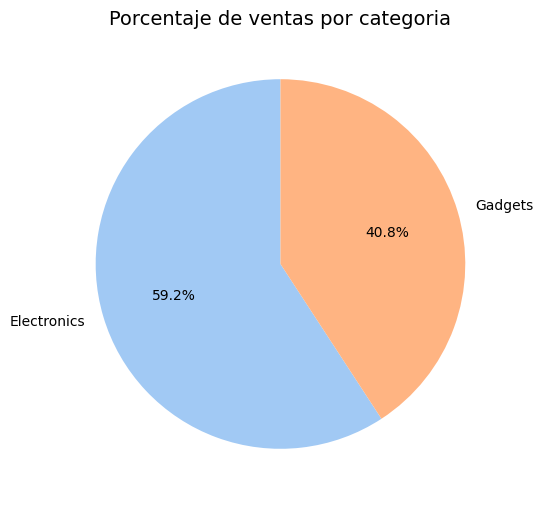

In [29]:
df["Category"] = df["Category"].replace({
    "Elec": "Electronics",
    "Gadget": "Gadgets"
})

plt.figure(figsize=(6,6))
category_sales = df.groupby("Category")["Total Sales"].sum()
plt.pie(category_sales, labels=category_sales.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Porcentaje de ventas por categoria", fontsize=14)
plt.show()

**Tarea 3: Realizar analisis por producto y por region** en diagrama de torta

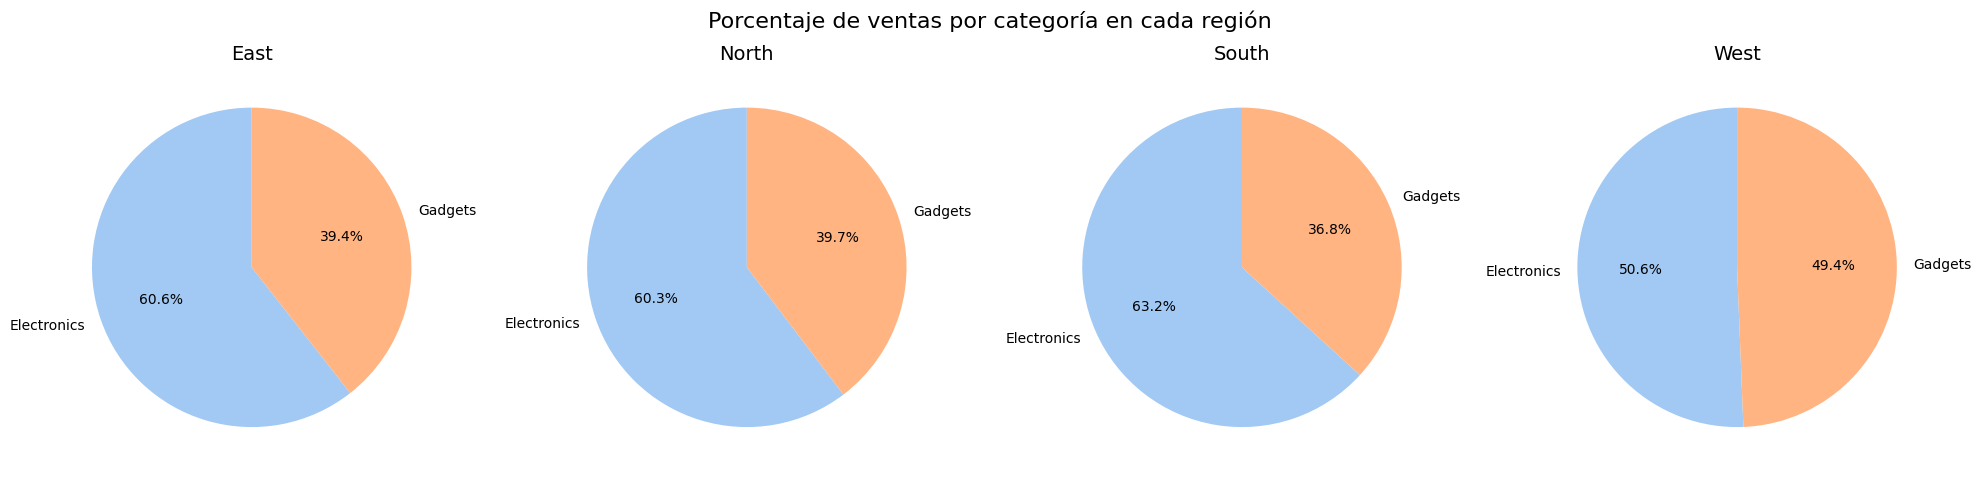

In [30]:
ventas = df.groupby(["Region", "Category"])["Total Sales"].sum().unstack()

fig, axes = plt.subplots(1, len(ventas), figsize=(5*len(ventas), 5))

for ax, (region, fila) in zip(axes, ventas.iterrows()):
    ax.pie(fila, labels=fila.index, autopct="%1.1f%%", startangle=90,
           colors=sns.color_palette("pastel"))
    ax.set_title(region, fontsize=14)

plt.suptitle("Porcentaje de ventas por categoría en cada región", fontsize=16)
plt.tight_layout()
plt.show()